# WiLLMa Stress Test V04

This notebook runs two comparable experiments:

1. a direct non-proxy stress test
2. a proxy-monitored stress test

The notebook is designed for a naive Data Scientist:

- one clear setup path
- one shared test runner
- one shared summary pipeline
- one final comparison between direct and proxy mode

The main question is simple: do both modes show the same failure pattern under higher concurrency?

## Notebook Logic

This notebook is intentionally linear.

- Step 1 checks the kernel
- Step 2 loads configuration and the API key
- Step 3 prepares optional proxy logging
- Step 4 discovers the model to test
- Step 5 defines one reusable request function
- Step 6 runs the direct experiment
- Step 7 runs the proxy experiment
- Step 8 summarizes and compares both runs
- Step 9 plots the results in a human-readable way
- Step 10 writes CSV outputs and a short conclusion

This avoids the main V03 problems: duplicated paths, mixed state, and ambiguity about which run produced which result.

In [1]:
#### CELL01: Kernel Integrity Check
from pathlib import Path
import platform
import sys

EXPECTED_KERNEL = "langflow-fixed-ORG"
EXPECTED_PYTHON = "3.10.19"
python_version = platform.python_version()
executable_name = Path(sys.executable).name.lower()
executable_path = str(Path(sys.executable)).lower()
kernel_matches = EXPECTED_KERNEL.lower() in executable_path or EXPECTED_KERNEL.lower() in executable_name
version_matches = python_version == EXPECTED_PYTHON

print(f"Python executable: {sys.executable}")
print(f"Python version: {python_version}")

if not kernel_matches or not version_matches:
    raise RuntimeError(
        "This notebook must run with the 'langflow-fixed-ORG' kernel using Python 3.10.19. "
        f"Current executable: {sys.executable}; current version: {python_version}"
    )

print("Kernel check passed.")

Python executable: c:\Users\PROMET02\anaconda3\envs\langflow-fixed-ORG\python.exe
Python version: 3.10.19
Kernel check passed.


## Key Terms

| Term | Meaning in this notebook |
|---|---|
| concurrency level | How many requests are sent in parallel at the same time |
| round | A repeat of the same concurrency level to check consistency |
| direct mode | Requests go straight from the notebook to WiLLMa |
| proxy mode | Requests go through mitmproxy before reaching WiLLMa |
| HTTP 429 | WiLLMa accepted the connection but refused the request because of rate limiting or throttling |
| request error | A local transport or connection problem before a valid HTTP response was received |
| success rate | Fraction of requests that returned HTTP 2xx |

In [2]:
#### CELL02: Imports, Paths, and Configuration
from pathlib import Path
import concurrent.futures
import json
import re
import subprocess
import time
import uuid
from datetime import datetime, timezone

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import requests

NOTEBOOK_ROOT = Path(r"D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS")
ENV_PATH = NOTEBOOK_ROOT / ".env"
ASSETS_DIR = NOTEBOOK_ROOT / "assets"
RESULTS_DIR = ASSETS_DIR / "results"
PROXY_DIR = ASSETS_DIR / "proxy"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PROXY_DIR.mkdir(parents=True, exist_ok=True)

WILLMA_DISCOVERY_URL = "https://api.willma.surf.nl/v0/sequences"
WILLMA_CHAT_URL = "https://willma.surf.nl/api/v0/chat/completions"
PROXY_BASE_URL = "http://127.0.0.1:8080"
PROXY_DISCOVERY_URL = f"{PROXY_BASE_URL}/v0/sequences"
PROXY_CHAT_URL = f"{PROXY_BASE_URL}/api/v0/chat/completions"

CONNECT_TIMEOUT_SECONDS = 30
READ_TIMEOUT_SECONDS = 180
VERIFY_TLS = True
TEMPERATURE = 0.2
MAX_TOKENS = 300
CONCURRENCY_LEVELS = [1, 5, 10, 15, 20]
ROUNDS_PER_LEVEL = 3
REQUESTS_PER_ROUND = 10
TEST_PROMPT = (
    "Explain in concise markdown what WiLLMa SURF is, what it is used for, "
    "and why a university teacher might use it in class."
)

print(f"Results directory: {RESULTS_DIR}")
print(f"Proxy directory: {PROXY_DIR}")
print(f"Concurrency levels: {CONCURRENCY_LEVELS}")
print(f"Rounds per level: {ROUNDS_PER_LEVEL}")
print(f"Requests per round: {REQUESTS_PER_ROUND}")

Results directory: D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\results
Proxy directory: D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\proxy
Concurrency levels: [1, 5, 10, 15, 20]
Rounds per level: 3
Requests per round: 10


In [3]:
#### CELL03: Load API Key From .env
def load_api_key(env_path: Path) -> str:
    if not env_path.exists():
        raise FileNotFoundError(f"Missing .env file: {env_path}")

    env_text = env_path.read_text(encoding="utf-8")
    for line in env_text.splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or "=" not in stripped:
            continue
        key, value = stripped.split("=", 1)
        if key.strip().upper() in {"WILLMA_API_KEY", "API_KEY", "X_API_KEY"}:
            api_key = value.strip().strip(chr(34)).strip(chr(39))
            if api_key:
                return api_key

    api_key_candidates = re.findall(r"[A-Za-z0-9]{20,}", env_text)
    if api_key_candidates:
        return api_key_candidates[0]

    raise ValueError(f"No usable API key found in {env_path}")

api_key = load_api_key(ENV_PATH)
HEADERS = {"X-API-KEY": api_key, "Content-Type": "application/json"}
print(f"API key loaded: {api_key[:12]}...{api_key[-4:]}")

API key loaded: 77696c6c6d61...856e


## Proxy Preparation

The notebook can run without a proxy.

For the proxy experiment, `mitmproxy` or `mitmdump` must already be running in a separate terminal.
This notebook writes the helper script and prints the command, but it does not try to manage the proxy process automatically.

That keeps the notebook understandable and avoids hidden background state.

In [9]:
#### CELL04: Write Proxy Logging Script and Show Command
proxy_log_path = PROXY_DIR / "mitmproxy.log"
proxy_script_path = PROXY_DIR / "save_streams.py"
proxy_script_lines = [
    "from mitmproxy import http",
    "from pathlib import Path",
    "from datetime import datetime, timezone",
    "import json",
    "",
    f"LOG_PATH = Path(r'{proxy_log_path}')",
    "LOG_PATH.parent.mkdir(parents=True, exist_ok=True)",
    "",
    "def _write_event(stage: str, flow: http.HTTPFlow):",
    "    event = {",
    '        "timestamp_utc": datetime.now(timezone.utc).isoformat(),',
    '        "stage": stage,',
    '        "method": flow.request.method,',
    '        "url": flow.request.pretty_url,',
    '        "path": flow.request.path,',
    '        "status_code": None if flow.response is None else flow.response.status_code,',
    '        "has_api_key": "X-API-KEY" in flow.request.headers,',
    '        "user_agent": flow.request.headers.get("User-Agent", ""),',
    "    }",
    '    with LOG_PATH.open("a", encoding="utf-8") as handle:',
    '        handle.write(json.dumps(event, ensure_ascii=False) + "\\n")',
    "",
    "def request(flow: http.HTTPFlow):",
    '    _write_event("request", flow)',
    "",
    "def response(flow: http.HTTPFlow):",
    '    _write_event("response", flow)',
]
proxy_script = "\n".join(proxy_script_lines) + "\n"
proxy_script_path.write_text(proxy_script, encoding="utf-8", newline="\n")

mitmdump_command = (
    f'mitmdump --mode reverse:https://api.willma.surf.nl -p 8080 -s "{proxy_script_path}"'
)

print(f"Proxy script written to: {proxy_script_path}")
print(f"Proxy log path: {proxy_log_path}")
print("Run this in a separate terminal before the proxy experiment:")
print(mitmdump_command)

Proxy script written to: D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\proxy\save_streams.py
Proxy log path: D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\proxy\mitmproxy.log
Run this in a separate terminal before the proxy experiment:
mitmdump --mode reverse:https://api.willma.surf.nl -p 8080 -s "D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\proxy\save_streams.py"


In [5]:
#### CELL05: Discover Available Models and Select Default
def discover_models(discovery_url: str) -> tuple[pd.DataFrame, list[str]]:
    response = requests.get(
        discovery_url,
        headers=HEADERS,
        timeout=(CONNECT_TIMEOUT_SECONDS, READ_TIMEOUT_SECONDS),
        verify=VERIFY_TLS,
    )
    print(f"Model discovery status: {response.status_code}")
    response.raise_for_status()
    payload = response.json()
    if not isinstance(payload, list):
        raise ValueError(f"Expected list from discovery endpoint, got {type(payload).__name__}")

    models_df = pd.DataFrame(payload)
    if "sequence_type" not in models_df.columns:
        models_df["sequence_type"] = "unknown"

    text_models = [
        row["name"]
        for _, row in models_df.iterrows()
        if str(row.get("sequence_type", "")).lower() == "text" and row.get("name")
    ]
    preferred_models = sorted(
        text_models,
        key=lambda name: (0 if "mistral" in name.lower() else 1, name.lower())
    )
    return models_df, preferred_models

models_df, text_models = discover_models(WILLMA_DISCOVERY_URL)
display(models_df[[col for col in ["id", "name", "sequence_type", "latency_mode"] if col in models_df.columns]])
print("\nCandidate text models:")
for model_name in text_models:
    print(f"- {model_name}")

if not text_models:
    raise ValueError("No text models discovered for testing.")

selected_model = text_models[0]
print(f"\nSelected model for V04: {selected_model}")

Model discovery status: 200


,id,name,sequence_type,latency_mode
0,42,meta-llama/Llama-Guard-3-8B,text,on-demand
1,44,mistralai/Mistral-Small-3.2-24B-Instruct-2506,text,always-on



Candidate text models:
- mistralai/Mistral-Small-3.2-24B-Instruct-2506
- meta-llama/Llama-Guard-3-8B

Selected model for V04: mistralai/Mistral-Small-3.2-24B-Instruct-2506


## Shared Test Functions

The next cell defines one reusable request function and one reusable experiment runner.

This is the main consistency improvement over V03: direct mode and proxy mode use the same logic, so the comparison is fair.

In [6]:
#### CELL06: Shared Request and Experiment Runner
def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def classify_status(http_status: int | None, exception_type: str | None) -> str:
    if exception_type == "timeout":
        return "timeout"
    if exception_type == "request_error":
        return "request_error"
    if http_status is None:
        return "unknown"
    if 200 <= http_status < 300:
        return "success"
    if http_status == 429:
        return "rate_limited"
    if http_status in (401, 403):
        return "not_authorized"
    if http_status == 404:
        return "not_found"
    if 500 <= http_status < 600:
        return "server_error"
    return f"http_{http_status}"

def run_one_request(mode_name: str, chat_url: str, model_name: str, prompt_text: str, concurrency_level: int, round_number: int, request_number: int) -> dict:
    payload = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": "You are a concise assistant."},
            {"role": "user", "content": prompt_text},
        ],
        "temperature": TEMPERATURE,
        "max_tokens": MAX_TOKENS,
        "stream": False,
    }

    started = time.perf_counter()
    response = None
    exception_type = None
    error_text = ""

    try:
        response = requests.post(
            chat_url,
            headers=HEADERS,
            json=payload,
            timeout=(CONNECT_TIMEOUT_SECONDS, READ_TIMEOUT_SECONDS),
            verify=VERIFY_TLS,
        )
        if not response.ok:
            error_text = response.text[:500]
    except requests.Timeout as exc:
        exception_type = "timeout"
        error_text = str(exc)
    except requests.RequestException as exc:
        exception_type = "request_error"
        error_text = str(exc)

    latency_seconds = round(time.perf_counter() - started, 4)
    http_status = None if response is None else response.status_code

    return {
        "timestamp_utc": utc_now_iso(),
        "request_id": uuid.uuid4().hex,
        "transport_mode": mode_name,
        "target_url": chat_url,
        "model": model_name,
        "concurrency_level": concurrency_level,
        "round_number": round_number,
        "request_number": request_number,
        "http_status": http_status,
        "status": classify_status(http_status, exception_type),
        "latency_seconds": latency_seconds,
        "retry_after": None if response is None else response.headers.get("Retry-After"),
        "error_text": error_text,
    }

def run_round(mode_name: str, chat_url: str, model_name: str, concurrency_level: int, round_number: int, requests_per_round: int) -> pd.DataFrame:
    with concurrent.futures.ThreadPoolExecutor(max_workers=concurrency_level) as executor:
        futures = [
            executor.submit(
                run_one_request,
                mode_name,
                chat_url,
                model_name,
                TEST_PROMPT,
                concurrency_level,
                round_number,
                request_number,
            )
            for request_number in range(1, requests_per_round + 1)
        ]
        rows = [future.result() for future in concurrent.futures.as_completed(futures)]
    return pd.DataFrame(rows).sort_values(by="request_number").reset_index(drop=True)

def run_experiment(mode_name: str, chat_url: str, model_name: str) -> pd.DataFrame:
    all_results = []
    print(f"Starting experiment: {mode_name}")
    for level in CONCURRENCY_LEVELS:
        for round_number in range(1, ROUNDS_PER_LEVEL + 1):
            print(f"Running {mode_name}: level {level}, round {round_number}/{ROUNDS_PER_LEVEL} with {REQUESTS_PER_ROUND} requests...")
            round_df = run_round(mode_name, chat_url, model_name, level, round_number, REQUESTS_PER_ROUND)
            all_results.append(round_df)
    results_df = pd.concat(all_results, ignore_index=True)
    print(f"Completed experiment: {mode_name}; rows = {len(results_df)}")
    return results_df

def summarize_level(level_df: pd.DataFrame) -> dict:
    latencies = level_df["latency_seconds"].dropna().tolist()
    http_errors = sorted({str(int(value)) for value in level_df["http_status"].dropna().tolist() if int(value) >= 400})
    return {
        "transport_mode": level_df["transport_mode"].iloc[0],
        "concurrency_level": int(level_df["concurrency_level"].iloc[0]),
        "total_requests": int(len(level_df)),
        "success_count": int((level_df["status"] == "success").sum()),
        "rate_limited_count": int((level_df["status"] == "rate_limited").sum()),
        "timeout_count": int((level_df["status"] == "timeout").sum()),
        "request_error_count": int((level_df["status"] == "request_error").sum()),
        "server_error_count": int((level_df["status"] == "server_error").sum()),
        "other_error_count": int((~level_df["status"].isin(["success", "rate_limited", "timeout", "request_error", "server_error"])).sum()),
        "success_rate": round((level_df["status"] == "success").mean(), 3),
        "avg_latency_seconds": round(sum(latencies) / len(latencies), 3) if latencies else None,
        "max_latency_seconds": round(max(latencies), 3) if latencies else None,
        "http_errors_seen": ", ".join(http_errors) if http_errors else "none",
    }

def build_summaries(results_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_df = pd.DataFrame([
        summarize_level(group)
        for _, group in results_df.groupby(["transport_mode", "concurrency_level"])
    ]).sort_values(by=["transport_mode", "concurrency_level"]).reset_index(drop=True)

    round_summary_df = (
        results_df.groupby(["transport_mode", "concurrency_level", "round_number"], dropna=False)
        .agg(
            total_requests=("request_id", "count"),
            success_count=("status", lambda values: int((values == "success").sum())),
            rate_limited_count=("status", lambda values: int((values == "rate_limited").sum())),
            timeout_count=("status", lambda values: int((values == "timeout").sum())),
            request_error_count=("status", lambda values: int((values == "request_error").sum())),
        )
        .reset_index()
    )
    round_summary_df["success_rate"] = (round_summary_df["success_count"] / round_summary_df["total_requests"]).round(3)
    return summary_df, round_summary_df

## Direct Experiment

This is the baseline.

If direct mode already fails at higher concurrency, then the proxy is not the root cause.

In [7]:
#### CELL07: Run Direct Non-Proxy Stress Test
RUN_DIRECT_EXPERIMENT = True

if RUN_DIRECT_EXPERIMENT:
    direct_results_df = run_experiment("direct", WILLMA_CHAT_URL, selected_model)
    display(direct_results_df.head(10))
else:
    direct_results_df = pd.DataFrame()
    print("Direct experiment skipped.")

Starting experiment: direct
Running direct: level 1, round 1/3 with 10 requests...
Running direct: level 1, round 2/3 with 10 requests...
Running direct: level 1, round 3/3 with 10 requests...
Running direct: level 5, round 1/3 with 10 requests...
Running direct: level 5, round 2/3 with 10 requests...
Running direct: level 5, round 3/3 with 10 requests...
Running direct: level 10, round 1/3 with 10 requests...
Running direct: level 10, round 2/3 with 10 requests...
Running direct: level 10, round 3/3 with 10 requests...
Running direct: level 15, round 1/3 with 10 requests...
Running direct: level 15, round 2/3 with 10 requests...
Running direct: level 15, round 3/3 with 10 requests...
Running direct: level 20, round 1/3 with 10 requests...
Running direct: level 20, round 2/3 with 10 requests...
Running direct: level 20, round 3/3 with 10 requests...
Completed experiment: direct; rows = 150


,timestamp_utc,request_id,transport_mode,target_url,model,concurrency_level,round_number,request_number,http_status,status,latency_seconds,retry_after,error_text
0,2026-08-05T13:59:58.534751+00:00,e95b3a3a90924fdbb273aa5c84d7a256,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,1,200,success,6.4260,None,
1,2026-08-05T14:00:04.335495+00:00,4d0a9d65bea343beba7474285e4f3420,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,2,200,success,5.7994,None,
2,2026-08-05T14:00:10.174947+00:00,a46d18082d13493f906e5d26f2f412ca,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,3,200,success,5.8381,None,
3,2026-08-05T14:00:16.652597+00:00,89dc2d2594c742389d7c303470bada13,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,4,200,success,6.4757,None,
4,2026-08-05T14:00:22.443635+00:00,ba900e4e69564461be1cba0edd99c72a,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,5,200,success,5.7899,None,
5,2026-08-05T14:00:27.665543+00:00,f7dd291f1a0348308e20c7454ba2a779,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,6,200,success,5.2194,None,
6,2026-08-05T14:00:34.672051+00:00,8e4efffa49274bfd825de93937eb271b,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,7,200,success,7.0049,None,
7,2026-08-05T14:00:40.910732+00:00,668b82e4e4bf416da702cfe1b936d752,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,8,200,success,6.2372,None,
8,2026-08-05T14:00:46.397878+00:00,ac41da79af304c1b9c8c2dafe8621d20,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,9,200,success,5.4853,None,
9,2026-08-05T14:00:52.317031+00:00,8b321cc47015486fb6339ffcce4f7156,direct,https://willma.surf.nl/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,10,200,success,5.9179,None,


## Proxy Experiment

This run uses the same logic as the direct run, but sends traffic through the local proxy.

If the direct and proxy patterns are similar, that supports the conclusion that the failures are upstream rather than introduced by the proxy.

In [10]:
#### CELL08: Run Proxy Monitoring Stress Test
RUN_PROXY_EXPERIMENT = True

if RUN_PROXY_EXPERIMENT:
    proxy_results_df = run_experiment("proxy", PROXY_CHAT_URL, selected_model)
    display(proxy_results_df.head(10))
else:
    proxy_results_df = pd.DataFrame()
    print("Proxy experiment skipped.")

Starting experiment: proxy
Running proxy: level 1, round 1/3 with 10 requests...
Running proxy: level 1, round 2/3 with 10 requests...
Running proxy: level 1, round 3/3 with 10 requests...
Running proxy: level 5, round 1/3 with 10 requests...
Running proxy: level 5, round 2/3 with 10 requests...
Running proxy: level 5, round 3/3 with 10 requests...
Running proxy: level 10, round 1/3 with 10 requests...
Running proxy: level 10, round 2/3 with 10 requests...
Running proxy: level 10, round 3/3 with 10 requests...
Running proxy: level 15, round 1/3 with 10 requests...
Running proxy: level 15, round 2/3 with 10 requests...
Running proxy: level 15, round 3/3 with 10 requests...
Running proxy: level 20, round 1/3 with 10 requests...
Running proxy: level 20, round 2/3 with 10 requests...
Running proxy: level 20, round 3/3 with 10 requests...
Completed experiment: proxy; rows = 150


,timestamp_utc,request_id,transport_mode,target_url,model,concurrency_level,round_number,request_number,http_status,status,latency_seconds,retry_after,error_text
0,2026-08-05T14:07:45.969429+00:00,17773e9d024d489da5d09263c3e1b019,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,1,200,success,7.0952,None,
1,2026-08-05T14:07:51.508279+00:00,c52ca678ab5b4c3499b4914cc5c06d04,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,2,200,success,5.5387,None,
2,2026-08-05T14:07:58.473459+00:00,c9d00443741c4f11a0d102f4c4ef91a2,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,3,200,success,6.9652,None,
3,2026-08-05T14:08:04.688980+00:00,15f01e54609945ee9ebba3c9d4b00207,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,4,200,success,6.2149,None,
4,2026-08-05T14:08:10.438855+00:00,174adce30dbc4d679f176c9bab2138b9,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,5,200,success,5.7496,None,
5,2026-08-05T14:08:16.319067+00:00,3895dfac48d64e969fb294d11d46015b,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,6,200,success,5.8798,None,
6,2026-08-05T14:08:21.323319+00:00,602ecaee37fd4f4f8c53bf0dd791b04f,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,7,200,success,5.0037,None,
7,2026-08-05T14:08:26.852603+00:00,dd2f7f6dd3eb41fc9a062a30b314e3e8,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,8,200,success,5.5293,None,
8,2026-08-05T14:08:33.109930+00:00,c3e5d57f51cf403da4932536e1dd744a,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,9,200,success,6.2567,None,
9,2026-08-05T14:08:40.808940+00:00,6efa53f0bdcc4b26bcc94338a76d7f11,proxy,http://127.0.0.1:8080/api/v0/chat/completions,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,10,200,success,7.6985,None,


## Combined Summary

The next cell combines both experiments into one table.

This is the main decision table for a naive Data Scientist.
It answers: where does success drop, and is the drop similar in both modes?

In [11]:
#### CELL09: Build Combined Summary Tables
available_results = [df for df in [direct_results_df, proxy_results_df] if not df.empty]
if not available_results:
    raise ValueError("No experiment results are available. Run at least one experiment first.")

combined_results_df = pd.concat(available_results, ignore_index=True)
summary_df, round_summary_df = build_summaries(combined_results_df)

comparison_df = summary_df[[
    "transport_mode",
    "concurrency_level",
    "success_rate",
    "rate_limited_count",
    "request_error_count",
    "timeout_count",
    "avg_latency_seconds",
    "http_errors_seen",
]].copy()

display(summary_df)
display(round_summary_df)
display(comparison_df)

,transport_mode,concurrency_level,total_requests,success_count,rate_limited_count,timeout_count,request_error_count,server_error_count,other_error_count,success_rate,avg_latency_seconds,max_latency_seconds,http_errors_seen
0,direct,1,30,30,0,0,0,0,0,1.0,6.160,7.317,none
1,direct,5,30,30,0,0,0,0,0,1.0,6.295,7.300,none
2,direct,10,30,15,15,0,0,0,0,0.5,3.222,7.269,429
3,direct,15,30,15,15,0,0,0,0,0.5,3.173,7.298,429
4,direct,20,30,15,15,0,0,0,0,0.5,3.325,7.919,429
5,proxy,1,30,30,0,0,0,0,0,1.0,6.093,7.699,none
6,proxy,5,30,30,0,0,0,0,0,1.0,6.423,8.264,none
7,proxy,10,30,15,15,0,0,0,0,0.5,3.316,8.476,429
8,proxy,15,30,15,15,0,0,0,0,0.5,3.568,7.826,429
9,proxy,20,30,15,15,0,0,0,0,0.5,3.517,8.598,429


,transport_mode,concurrency_level,round_number,total_requests,success_count,rate_limited_count,timeout_count,request_error_count,success_rate
0,direct,1,1,10,10,0,0,0,1.0
1,direct,1,2,10,10,0,0,0,1.0
2,direct,1,3,10,10,0,0,0,1.0
3,direct,5,1,10,10,0,0,0,1.0
4,direct,5,2,10,10,0,0,0,1.0
5,direct,5,3,10,10,0,0,0,1.0
6,direct,10,1,10,5,5,0,0,0.5
7,direct,10,2,10,5,5,0,0,0.5
8,direct,10,3,10,5,5,0,0,0.5
9,direct,15,1,10,5,5,0,0,0.5


,transport_mode,concurrency_level,success_rate,rate_limited_count,request_error_count,timeout_count,avg_latency_seconds,http_errors_seen
0,direct,1,1.0,0,0,0,6.160,none
1,direct,5,1.0,0,0,0,6.295,none
2,direct,10,0.5,15,0,0,3.222,429
3,direct,15,0.5,15,0,0,3.173,429
4,direct,20,0.5,15,0,0,3.325,429
5,proxy,1,1.0,0,0,0,6.093,none
6,proxy,5,1.0,0,0,0,6.423,none
7,proxy,10,0.5,15,0,0,3.316,429
8,proxy,15,0.5,15,0,0,3.568,429
9,proxy,20,0.5,15,0,0,3.517,429


## Plot Interpretation

How to read the plots:

- If both lines drop at about the same concurrency, the proxy is probably not the cause.
- If only the proxy line drops, inspect the proxy setup first.
- If failures are mostly orange HTTP 429 bars, WiLLMa is responding but throttling.
- If failures are mostly red request-error bars, the problem is more likely local transport or proxy setup.

Saved plot image to D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\results\willma_v04_direct_vs_proxy_plots.png


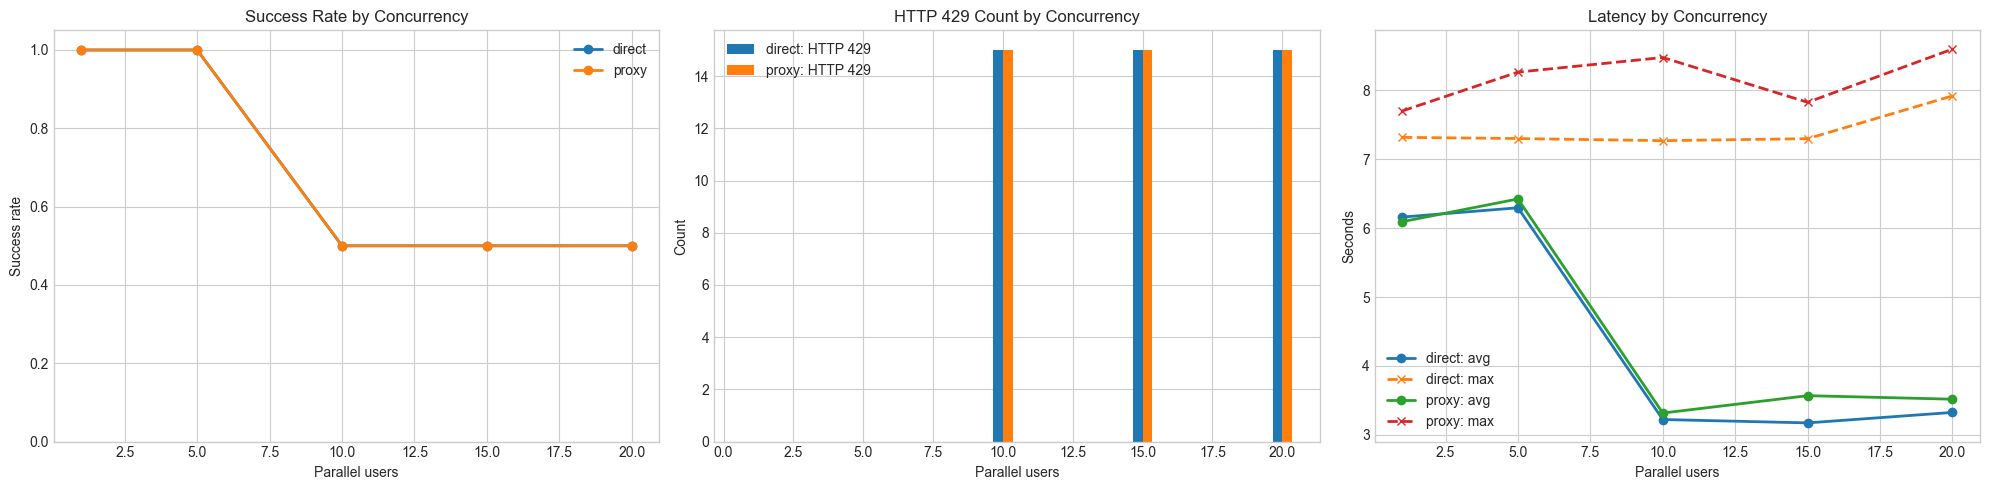

In [12]:
#### CELL10: Plot Direct Versus Proxy Results
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for mode_name, mode_df in summary_df.groupby("transport_mode"):
    axes[0].plot(mode_df["concurrency_level"], mode_df["success_rate"], marker="o", linewidth=2, label=mode_name)
axes[0].set_title("Success Rate by Concurrency")
axes[0].set_xlabel("Parallel users")
axes[0].set_ylabel("Success rate")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

plot_modes = list(summary_df["transport_mode"].unique())
bar_width = 0.35
for index, mode_name in enumerate(plot_modes):
    mode_df = summary_df.loc[summary_df["transport_mode"] == mode_name].sort_values("concurrency_level")
    x_positions = [value + (index - (len(plot_modes) - 1) / 2) * bar_width for value in mode_df["concurrency_level"]]
    axes[1].bar(x_positions, mode_df["rate_limited_count"], width=bar_width, label=f"{mode_name}: HTTP 429")
axes[1].set_title("HTTP 429 Count by Concurrency")
axes[1].set_xlabel("Parallel users")
axes[1].set_ylabel("Count")
axes[1].legend()

for mode_name, mode_df in summary_df.groupby("transport_mode"):
    axes[2].plot(mode_df["concurrency_level"], mode_df["avg_latency_seconds"], marker="o", linewidth=2, label=f"{mode_name}: avg")
    axes[2].plot(mode_df["concurrency_level"], mode_df["max_latency_seconds"], marker="x", linewidth=2, linestyle="--", label=f"{mode_name}: max")
axes[2].set_title("Latency by Concurrency")
axes[2].set_xlabel("Parallel users")
axes[2].set_ylabel("Seconds")
axes[2].legend()

plt.tight_layout()
plot_path = RESULTS_DIR / "willma_v04_direct_vs_proxy_plots.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot image to {plot_path}")
plt.show()

## Optional Proxy Log Analysis

This cell is optional.

Use it only if you ran the proxy experiment and the proxy log file exists.
It helps connect the notebook results to the actual HTTP traffic seen by the proxy.

In [ ]:
#### CELL11: Optional Proxy Log Summary and Dedicated Proxy Plot
if proxy_log_path.exists():
    proxy_log_text = proxy_log_path.read_text(encoding="utf-8")
    proxy_events = []

    for line in proxy_log_text.splitlines():
        stripped = line.strip()
        if not stripped:
            continue
        if stripped.startswith("{") and stripped.endswith("}"):
            try:
                proxy_events.append(json.loads(stripped))
            except json.JSONDecodeError:
                pass

    if not proxy_events:
        request_pattern = re.compile(
            r"=== REQUEST ===\s*(?P<timestamp>[^\r\n]+)\s*(?P<method>[A-Z]+)\s+(?P<url>https?://\S+)(?P<headers>.*?)(?=(?:=== RESPONSE ===)|(?:=== REQUEST ===)|\Z)",
            re.DOTALL,
        )
        response_pattern = re.compile(
            r"=== RESPONSE ===\s*(?P<timestamp>[^\r\n]+)(?P<body>.*?)(?=(?:=== REQUEST ===)|(?:=== RESPONSE ===)|\Z)",
            re.DOTALL,
        )

        request_matches = list(request_pattern.finditer(proxy_log_text))
        response_matches = list(response_pattern.finditer(proxy_log_text))

        for index, request_match in enumerate(request_matches):
            headers_text = request_match.group("headers")
            url = request_match.group("url").strip()
            proxy_events.append({
                "timestamp_utc": request_match.group("timestamp").strip(),
                "stage": "request",
                "method": request_match.group("method").strip(),
                "url": url,
                "path": re.sub(r"^https?://[^/]+", "", url),
                "status_code": None,
                "has_api_key": "x-api-key:" in headers_text.lower(),
                "user_agent": next((
                    header_line.split(":", 1)[1].strip()
                    for header_line in headers_text.splitlines()
                    if header_line.lower().startswith("user-agent:")
                ), ""),
            })

            if index < len(response_matches):
                response_body = response_matches[index].group("body")
                status_match = re.search(r"Status:\s*(\d+)", response_body)
                proxy_events.append({
                    "timestamp_utc": response_matches[index].group("timestamp").strip(),
                    "stage": "response",
                    "method": request_match.group("method").strip(),
                    "url": url,
                    "path": re.sub(r"^https?://[^/]+", "", url),
                    "status_code": None if status_match is None else int(status_match.group(1)),
                    "has_api_key": "x-api-key:" in headers_text.lower(),
                    "user_agent": next((
                        header_line.split(":", 1)[1].strip()
                        for header_line in headers_text.splitlines()
                        if header_line.lower().startswith("user-agent:")
                    ), ""),
                })

    proxy_events_df = pd.DataFrame(proxy_events)
    if proxy_events_df.empty:
        print("Proxy log exists but no readable events were found.")
    else:
        for column_name, default_value in {
            "timestamp_utc": pd.NaT,
            "stage": "unknown",
            "method": None,
            "url": None,
            "path": None,
            "status_code": None,
            "has_api_key": False,
            "user_agent": "",
        }.items():
            if column_name not in proxy_events_df.columns:
                proxy_events_df[column_name] = default_value

        proxy_events_df["timestamp_utc"] = pd.to_datetime(proxy_events_df["timestamp_utc"], utc=True, errors="coerce")
        proxy_events_df["status_code"] = pd.to_numeric(proxy_events_df["status_code"], errors="coerce")
        proxy_events_df["status_family"] = proxy_events_df["status_code"].apply(lambda value: "no_response" if pd.isna(value) else f"{int(value) // 100}xx")
        proxy_events_df["status_label"] = proxy_events_df["status_code"].apply(lambda value: "no_response" if pd.isna(value) else str(int(value)))
        proxy_events_df["is_browser_like"] = proxy_events_df["user_agent"].fillna("").str.contains("Mozilla|Chrome|Safari|Edge", case=False, regex=True)
        proxy_events_df["is_notebook_api_call"] = proxy_events_df["has_api_key"].fillna(False) & (~proxy_events_df["is_browser_like"])

        request_events_df = proxy_events_df.loc[proxy_events_df["stage"] == "request"].copy()
        response_events_df = proxy_events_df.loc[proxy_events_df["stage"] == "response"].copy()
        request_events_df = request_events_df.rename(columns={"timestamp_utc": "request_timestamp"})
        response_events_df = response_events_df.rename(columns={"timestamp_utc": "response_timestamp"})

        request_events_df["event_key"] = range(len(request_events_df))
        response_events_df["event_key"] = range(len(response_events_df))
        merge_columns = ["event_key", "method", "url", "path", "has_api_key", "user_agent"]
        proxy_pairs_df = request_events_df[["request_timestamp"] + merge_columns].merge(
            response_events_df[["response_timestamp", "status_code", "status_family", "status_label", "event_key"]],
            on="event_key",
            how="left"
        )
        proxy_pairs_df["is_browser_like"] = proxy_pairs_df["user_agent"].fillna("").str.contains("Mozilla|Chrome|Safari|Edge", case=False, regex=True)
        proxy_pairs_df["is_notebook_api_call"] = proxy_pairs_df["has_api_key"].fillna(False) & (~proxy_pairs_df["is_browser_like"])
        proxy_pairs_df["event_timestamp"] = proxy_pairs_df["response_timestamp"].fillna(proxy_pairs_df["request_timestamp"])
        proxy_pairs_df["elapsed_seconds"] = (proxy_pairs_df["response_timestamp"] - proxy_pairs_df["request_timestamp"]).dt.total_seconds()
        proxy_pairs_df["status_family"] = proxy_pairs_df["status_family"].fillna("no_response")
        proxy_pairs_df["status_label"] = proxy_pairs_df["status_label"].fillna("no_response")
        proxy_pairs_df = proxy_pairs_df.sort_values("event_timestamp").reset_index(drop=True)

        notebook_proxy_df = proxy_pairs_df.loc[proxy_pairs_df["is_notebook_api_call"]].copy()
        if notebook_proxy_df.empty:
            notebook_proxy_df = proxy_pairs_df.copy()

        display(notebook_proxy_df.tail(20))

        status_counts_df = (
            notebook_proxy_df.groupby(["status_label", "status_family"], dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values(by=["status_family", "status_label"])
            .reset_index(drop=True)
        )
        display(status_counts_df)

        proxy_summary_for_plot = pd.DataFrame()
        if "proxy_results_df" in globals() and not proxy_results_df.empty:
            proxy_summary_for_plot, _ = build_summaries(proxy_results_df)

        status_colors = {"2xx": "#2E8B57", "4xx": "#E67E22", "5xx": "#C0392B", "no_response": "#7F8C8D"}
        notebook_proxy_df["plot_color"] = notebook_proxy_df["status_family"].map(status_colors).fillna("#4C78A8")

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))

        axes[0, 0].scatter(
            notebook_proxy_df["event_timestamp"],
            notebook_proxy_df["status_code"].fillna(-1),
            c=notebook_proxy_df["plot_color"],
            alpha=0.8
        )
        axes[0, 0].set_title("Proxy Events Over Time")
        axes[0, 0].set_xlabel("Timestamp (UTC)")
        axes[0, 0].set_ylabel("HTTP status")

        axes[0, 1].bar(status_counts_df["status_label"], status_counts_df["count"], color=[status_colors.get(family, "#4C78A8") for family in status_counts_df["status_family"]])
        axes[0, 1].set_title("Proxy Status Counts")
        axes[0, 1].set_xlabel("HTTP status")
        axes[0, 1].set_ylabel("Count")

        latency_df = notebook_proxy_df.dropna(subset=["elapsed_seconds"]).copy()
        if not latency_df.empty:
            axes[1, 0].plot(latency_df["event_timestamp"], latency_df["elapsed_seconds"], marker="o", linewidth=1.5, color="#4C78A8")
            axes[1, 0].set_title("Proxy Observed Latency Over Time")
            axes[1, 0].set_xlabel("Timestamp (UTC)")
            axes[1, 0].set_ylabel("Seconds")
        else:
            axes[1, 0].text(0.5, 0.5, "No request/response latency pairs found", ha="center", va="center", transform=axes[1, 0].transAxes)
            axes[1, 0].set_title("Proxy Observed Latency Over Time")
            axes[1, 0].set_axis_off()

        if not proxy_summary_for_plot.empty:
            axes[1, 1].plot(proxy_summary_for_plot["concurrency_level"], proxy_summary_for_plot["success_rate"], marker="o", linewidth=2, color="#2E8B57", label="success rate")
            axes[1, 1].bar(proxy_summary_for_plot["concurrency_level"], proxy_summary_for_plot["rate_limited_count"], alpha=0.35, color="#E67E22", label="HTTP 429 count")
            axes[1, 1].set_title("Proxy Stress-Test Summary by Concurrency")
            axes[1, 1].set_xlabel("Concurrency level")
            axes[1, 1].set_ylabel("Value")
            axes[1, 1].set_xticks(proxy_summary_for_plot["concurrency_level"].tolist())
            axes[1, 1].legend()
        else:
            axes[1, 1].text(0.5, 0.5, "Run the proxy experiment first to populate this panel", ha="center", va="center", transform=axes[1, 1].transAxes)
            axes[1, 1].set_title("Proxy Stress-Test Summary by Concurrency")
            axes[1, 1].set_axis_off()

        legend_handles = [
            Patch(facecolor="#2E8B57", label="2xx: successful upstream response"),
            Patch(facecolor="#E67E22", label="4xx: client-visible refusal, often 429 throttling"),
            Patch(facecolor="#C0392B", label="5xx: upstream server-side failure"),
            Patch(facecolor="#7F8C8D", label="no response: request seen without matching response"),
        ]
        fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False)
        fig.suptitle("V04 Proxy Diagnostics", fontsize=16)
        fig.tight_layout(rect=[0, 0.06, 1, 0.95])

        proxy_plot_path = PROXY_DIR / "PROXY-TESTS-V04.png"
        fig.savefig(proxy_plot_path, dpi=150, bbox_inches="tight")
        print(f"Saved proxy diagnostics plot to {proxy_plot_path}")
        plt.show()
else:
    print(f"Proxy log not found: {proxy_log_path}")

C:\Users\PROMET02\AppData\Local\Temp\ipykernel_284400\2742456041.py:87: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  proxy_events_df["is_notebook_api_call"] = proxy_events_df["has_api_key"].fillna(False) & (~proxy_events_df["is_browser_like"])
C:\Users\PROMET02\AppData\Local\Temp\ipykernel_284400\2742456041.py:103: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  proxy_pairs_df["is_notebook_api_call"] = proxy_pairs_df["has_api_key"].fillna(False) & (~proxy_pairs_df["is_browser_like"])


,request_timestamp,event_key,method,url,path,has_api_key,user_agent,response_timestamp,status_code,status_family,status_label,is_browser_like,is_notebook_api_call,event_timestamp,elapsed_seconds
130,2026-08-05 14:12:17.737891+00:00,130,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:17.870404+00:00,429.0,4xx,429,False,True,2026-08-05 14:12:17.870404+00:00,0.132513
131,2026-08-05 14:12:17.739890+00:00,131,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:17.890971+00:00,429.0,4xx,429,False,True,2026-08-05 14:12:17.890971+00:00,0.151081
132,2026-08-05 14:12:17.743892+00:00,132,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:17.894977+00:00,429.0,4xx,429,False,True,2026-08-05 14:12:17.894977+00:00,0.151085
133,2026-08-05 14:12:17.759890+00:00,133,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:17.896979+00:00,429.0,4xx,429,False,True,2026-08-05 14:12:17.896979+00:00,0.137089
134,2026-08-05 14:12:17.768892+00:00,134,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:17.909977+00:00,429.0,4xx,429,False,True,2026-08-05 14:12:17.909977+00:00,0.141085
135,2026-08-05 14:12:17.781895+00:00,135,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:23.847619+00:00,200.0,2xx,200,False,True,2026-08-05 14:12:23.847619+00:00,6.065724
136,2026-08-05 14:12:17.789895+00:00,136,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:23.935730+00:00,200.0,2xx,200,False,True,2026-08-05 14:12:23.935730+00:00,6.145835
137,2026-08-05 14:12:17.791400+00:00,137,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:24.050813+00:00,200.0,2xx,200,False,True,2026-08-05 14:12:24.050813+00:00,6.259413
138,2026-08-05 14:12:17.796403+00:00,138,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:24.606063+00:00,200.0,2xx,200,False,True,2026-08-05 14:12:24.606063+00:00,6.809660
139,2026-08-05 14:12:17.798405+00:00,139,POST,https://api.willma.surf.nl/api/v0/chat/complet...,/api/v0/chat/completions,True,python-requests/2.32.5,2026-08-05 14:12:25.749804+00:00,200.0,2xx,200,False,True,2026-08-05 14:12:25.749804+00:00,7.951399


,status_label,status_family,count
0,200,2xx,105
1,429,4xx,45


In [14]:
#### CELL12: Final Conclusion and Save CSV Outputs
timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

direct_summary = summary_df.loc[summary_df["transport_mode"] == "direct"]
proxy_summary = summary_df.loc[summary_df["transport_mode"] == "proxy"]

direct_has_429 = int(direct_summary["rate_limited_count"].sum()) > 0 if not direct_summary.empty else False
proxy_has_429 = int(proxy_summary["rate_limited_count"].sum()) > 0 if not proxy_summary.empty else False
direct_has_request_errors = int(direct_summary["request_error_count"].sum()) > 0 if not direct_summary.empty else False
proxy_has_request_errors = int(proxy_summary["request_error_count"].sum()) > 0 if not proxy_summary.empty else False

if not direct_summary.empty and not proxy_summary.empty and direct_has_429 and proxy_has_429:
    likely_interpretation = "Direct mode and proxy mode both show HTTP 429 under higher concurrency. This supports an upstream WiLLMa throttling explanation rather than a proxy-only problem."
elif not direct_summary.empty and not proxy_summary.empty and (not direct_has_429) and proxy_has_429:
    likely_interpretation = "Only proxy mode shows HTTP 429 in this run. Inspect proxy setup, timing, and whether the two runs were truly comparable."
elif direct_has_request_errors or proxy_has_request_errors:
    likely_interpretation = "At least one mode shows local request errors. Inspect transport, connectivity, and proxy configuration before concluding this is purely upstream throttling."
else:
    likely_interpretation = "The result is mixed. Use the summary tables and proxy log together before drawing a final conclusion."

conclusion_lines = [
    f"Selected model: {selected_model}",
    f"Direct run executed: {not direct_results_df.empty}",
    f"Proxy run executed: {not proxy_results_df.empty}",
    f"Direct HTTP 429 total: {int(direct_summary['rate_limited_count'].sum()) if not direct_summary.empty else 0}",
    f"Proxy HTTP 429 total: {int(proxy_summary['rate_limited_count'].sum()) if not proxy_summary.empty else 0}",
    f"Direct request error total: {int(direct_summary['request_error_count'].sum()) if not direct_summary.empty else 0}",
    f"Proxy request error total: {int(proxy_summary['request_error_count'].sum()) if not proxy_summary.empty else 0}",
    f"Likely interpretation: {likely_interpretation}",
    f"Proxy log path: {proxy_log_path}",
]

print("Conclusion:\n")
for line in conclusion_lines:
    print(f"- {line}")

conclusion_df = pd.DataFrame({"statement": conclusion_lines})
display(conclusion_df)

combined_results_df.to_csv(RESULTS_DIR / f"willma_v04_raw_results_{timestamp}.csv", index=False)
summary_df.to_csv(RESULTS_DIR / f"willma_v04_summary_{timestamp}.csv", index=False)
round_summary_df.to_csv(RESULTS_DIR / f"willma_v04_round_summary_{timestamp}.csv", index=False)
conclusion_df.to_csv(RESULTS_DIR / f"willma_v04_conclusion_{timestamp}.csv", index=False)
print(f"\nSaved CSV outputs to {RESULTS_DIR}")

Conclusion:

- Selected model: mistralai/Mistral-Small-3.2-24B-Instruct-2506
- Direct run executed: True
- Proxy run executed: True
- Direct HTTP 429 total: 45
- Proxy HTTP 429 total: 45
- Direct request error total: 0
- Proxy request error total: 0
- Likely interpretation: Direct mode and proxy mode both show HTTP 429 under higher concurrency. This supports an upstream WiLLMa throttling explanation rather than a proxy-only problem.
- Proxy log path: D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\proxy\mitmproxy.log


,statement
0,Selected model: mistralai/Mistral-Small-3.2-24...
1,Direct run executed: True
2,Proxy run executed: True
3,Direct HTTP 429 total: 45
4,Proxy HTTP 429 total: 45
5,Direct request error total: 0
6,Proxy request error total: 0
7,Likely interpretation: Direct mode and proxy m...
8,Proxy log path: D:\OneDrive - Hogeschool Rotte...



Saved CSV outputs to D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\results
